In [2]:
from pathlib import Path
import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- 1. XỬ LÝ ĐƯỜNG DẪN AN TOÀN (PATHLIB) ---
try:
  PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
  # Dự phòng nếu bạn chạy code này trực tiếp trong Jupyter / PyCharm Notebook
  PROJECT_ROOT = Path('.').resolve().parent

DATA_DIR = PROJECT_ROOT / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)  # Tự động tạo thư mục data/ nếu chưa có

# Định nghĩa chính xác vị trí file đọc & xuất
input_csv_file = DATA_DIR / 'amazon_electronics_data_cleaned.csv'
output_file_40k = DATA_DIR / 'first_40000_rows.csv'
output_file_remaining = DATA_DIR / 'remaining_rows.csv'

target_col = 'purchased_last_month'
rows_to_take = 40000

# --- 2. THỰC HIỆN ĐỌC VÀ PHÂN TÁCH DỮ LIỆU ---
try:
  # Đọc dữ liệu
  df = pd.read_csv(input_csv_file)
  print(f'📊 Tổng số dòng trong file gốc: {len(df):,}')

  # Phân loại dựa trên dữ liệu cột target
  df_has_target = df[df[target_col].notna()].copy()  # Dòng SẠCH (có lượt bán)
  df_missing_target = df[
      df[target_col].isna()
  ].copy()  # Dòng TRỐNG (cần dự đoán)

  print(f' Output - Số dòng ĐÃ CÓ lượt bán: {len(df_has_target):,}')
  print(f' Output - Số dòng BỊ TRỐNG lượt bán: {len(df_missing_target):,}')

  # Lấy 40,000 dòng SẠCH để làm tập Train
  if len(df_has_target) >= rows_to_take:
    df_first_part = df_has_target.iloc[:rows_to_take]
    df_remaining_has_target = df_has_target.iloc[rows_to_take:]
  else:
    print(
        f'\n⚠️ Cảnh báo: Chỉ có {len(df_has_target):,} dòng sạch, ít hơn mức'
        f' {rows_to_take:,} yêu cầu.'
    )
    df_first_part = df_has_target
    df_remaining_has_target = pd.DataFrame()

  # Gộp phần dư sạch (nếu có) + toàn bộ dòng thiếu lượt bán làm tập Predict
  df_remaining_part = pd.concat(
      [df_remaining_has_target, df_missing_target], ignore_index=False
  )

  # Lưu file trực tiếp vào thư mục data/
  df_first_part.to_csv(output_file_40k, index=False)
  print(
      f"\n✅ Đã lưu {len(df_first_part):,} dòng SẠCH vào: '{output_file_40k}'"
  )

  df_remaining_part.to_csv(output_file_remaining, index=False)
  print(
      f"✅ Đã lưu {len(df_remaining_part):,} dòng còn lại vào:"
      f" '{output_file_remaining}'"
  )

except FileNotFoundError:
  print(
      f"❌ Lỗi: Không tìm thấy tệp '{input_csv_file}'. Vui lòng kiểm tra lại"
      ' đường dẫn.'
  )
except Exception as e:
  print(f'❌ Đã xảy ra lỗi: {e}')

📊 Tổng số dòng trong file gốc: 42,675
 Output - Số dòng ĐÃ CÓ lượt bán: 32,164
 Output - Số dòng BỊ TRỐNG lượt bán: 10,511

⚠️ Cảnh báo: Chỉ có 32,164 dòng sạch, ít hơn mức 40,000 yêu cầu.

✅ Đã lưu 32,164 dòng SẠCH vào: 'C:\Users\Thai Vi\PycharmProjects\Analyze&ForecastSaleSystem\data\first_40000_rows.csv'
✅ Đã lưu 10,511 dòng còn lại vào: 'C:\Users\Thai Vi\PycharmProjects\Analyze&ForecastSaleSystem\data\remaining_rows.csv'


In [3]:
# Kiểm tra biến df_first_part có tồn tại và là DataFrame hay không
if 'df_first_part' in locals() and isinstance(df_first_part, pd.DataFrame):
  print('✅ Các cột có sẵn trong df_first_part:')
  print(df_first_part.columns.tolist())
else:
  print(
      "⚠️ Biến 'df_first_part' chưa được tạo hoặc đang bị lỗi!"
  )
  print(
      '👉 Vui lòng kiểm tra lại cell xử lý dữ liệu ở bước trước và đảm bảo cell'
      ' đó đã chạy thành công.'
  )

✅ Các cột có sẵn trong df_first_part:
['product_title', 'product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'delivery_date', 'sustainability_tags', 'product_image_url', 'product_page_url', 'data_collected_at', 'product_category', 'discount_percentage']


In [7]:
print("Bắt đầu xây dựng & tối ưu tham số các mô hình dự đoán...")

# ==========================================
# 1. DATA PREPARATION & FEATURE ENGINEERING
# ==========================================
target = 'purchased_last_month'
numerical_features = [
    'product_rating',
    'total_reviews',
    'discounted_price',
    'original_price',
]

categorical_features = [
    'is_best_seller',
    'is_sponsored',
    'has_coupon',
    'buy_box_availability',
    'product_category',
]

# Kiểm tra các cột tồn tại trong DataFrame
available_features = [
    col
    for col in (numerical_features + categorical_features)
    if col in df_first_part.columns
]
numerical_features = [
    col for col in numerical_features if col in available_features
]
categorical_features = [
    col for col in categorical_features if col in available_features
]

# Loại bỏ các dòng bị thiếu target
df_model = df_first_part.dropna(subset=[target]).copy()

# Feature Engineering: Discount Percentage
df_model['discount_percentage'] = np.where(
    df_model['original_price'] > 0,
    (
        (df_model['original_price'] - df_model['discounted_price'])
        / df_model['original_price']
    )
    * 100,
    0,
)

if 'discount_percentage' not in numerical_features:
  numerical_features.append('discount_percentage')

print(f"Số lượng dòng tập Train/Validation: {len(df_model)} dòng")

# Tách X và y
X = df_model[numerical_features + categorical_features]
y = df_model[target]

# Split dữ liệu (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Kích thước tập huấn luyện: {len(X_train)} dòng")
print(f"Kích thước tập kiểm tra: {len(X_test)} dòng")

# ==========================================
# 2. PIPELINES & PREPROCESSING
# ==========================================
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
)

# ==========================================
# 3. MODEL TRAINING WITH OPTIMIZED HYPERPARAMETERS
# ==========================================
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    'Gradient Boosting Regressor': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        min_samples_split=5,
        random_state=42,
    ),
    'LightGBM Regressor': lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
}

results = {}
best_model_name = None
best_mae = float('inf')
best_full_pipeline = None

for name, model in models.items():
  print(f"\nĐang huấn luyện & tối ưu: {name}...")

  full_pipeline = Pipeline(
      steps=[('preprocessor', preprocessor), ('regressor', model)]
  )

  # Fit mô hình
  full_pipeline.fit(X_train, y_train)

  # Dự đoán tập test
  y_pred = full_pipeline.predict(X_test)

  # Đánh giá chỉ số
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

  print(
      f"✓ {name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2:"
      f" {r2:.2f}"
  )

  if mae < best_mae:
    best_mae = mae
    best_model_name = name
    best_full_pipeline = full_pipeline

# ==========================================
# 4. SO SÁNH & LƯU MÔ HÌNH TỐI ƯU NHẤT
# ==========================================
print("\n" + "=" * 40)
print("BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH ĐÃ TỐI ƯU")
print("=" * 40)
for name, metrics in results.items():
  print(f"Mô hình: {name}")
  print(f"  MAE:  {metrics['MAE']:.2f}")
  print(f"  MSE:  {metrics['MSE']:.2f}")
  print(f"  RMSE: {metrics['RMSE']:.2f}")
  print(f"  R2:   {metrics['R2']:.2f}")
  print("-" * 30)

print(
    f"\n🏆 MÔ HÌNH TỐI ƯU NHẤT: {best_model_name} (MAE đạt mức thấp nhất:"
    f" {best_mae:.2f})"
)

# 1. Xác định đường dẫn gốc của dự án (PROJECT_ROOT)
try:
  PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
  # Tự động xử lý nếu chạy trong Jupyter / PyCharm Notebook
  PROJECT_ROOT = Path('.').resolve().parent

# 2. Định nghĩa và tự động tạo thư mục saved_artifacts/ nếu chưa tồn tại
ARTIFACTS_DIR = PROJECT_ROOT / 'saved_artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# 3. Đặt tên file và nối thành đường dẫn tuyệt đối chuẩn
model_filename = (
    f'{best_model_name.replace(" ", "_").lower()}_best_sales_model.joblib'
)
model_save_path = ARTIFACTS_DIR / model_filename

# 4. Lưu mô hình vào đúng thư mục saved_artifacts/
joblib.dump(best_full_pipeline, model_save_path)

print(
    '✓ Đã lưu pipeline mô hình tốt nhất vào:'
    f" '{model_save_path.relative_to(PROJECT_ROOT)}'"
)

Bắt đầu xây dựng & tối ưu tham số các mô hình dự đoán...
Số lượng dòng tập Train/Validation: 32164 dòng
Kích thước tập huấn luyện: 25731 dòng
Kích thước tập kiểm tra: 6433 dòng

Đang huấn luyện & tối ưu: Linear Regression...
✓ Linear Regression - MAE: 1689.82, MSE: 23744614.81, RMSE: 4872.84, R2: 0.28

Đang huấn luyện & tối ưu: Random Forest Regressor...
✓ Random Forest Regressor - MAE: 299.02, MSE: 3241062.90, RMSE: 1800.30, R2: 0.90

Đang huấn luyện & tối ưu: Gradient Boosting Regressor...
✓ Gradient Boosting Regressor - MAE: 356.60, MSE: 3023224.50, RMSE: 1738.74, R2: 0.91

Đang huấn luyện & tối ưu: LightGBM Regressor...
✓ LightGBM Regressor - MAE: 342.69, MSE: 2670653.29, RMSE: 1634.21, R2: 0.92

BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH ĐÃ TỐI ƯU
Mô hình: Linear Regression
  MAE:  1689.82
  MSE:  23744614.81
  RMSE: 4872.84
  R2:   0.28
------------------------------
Mô hình: Random Forest Regressor
  MAE:  299.02
  MSE:  3241062.90
  RMSE: 1800.30
  R2:   0.90
----------------------------

In [8]:
print("Lượt bán trung bình thực tế:", y_test.mean())
print("Tỷ lệ MAE / Mean:", (267.92 / y_test.mean()) * 100, "%")

train_r2 = best_full_pipeline.score(X_train, y_train)
test_r2 = best_full_pipeline.score(X_test, y_test)

print(f"R2 trên tập Train: {train_r2:.2f}")
print(f"R2 trên tập Test:  {test_r2:.2f}")

Lượt bán trung bình thực tế: 1217.7677599875642
Tỷ lệ MAE / Mean: 22.00091091282758 %
R2 trên tập Train: 0.96
R2 trên tập Test:  0.90


⏳ Đang tính toán Feature Importance & SHAP Values từ File Model...
✅ Đã load thành công Pipeline từ: random_forest_regressor_best_sales_model.joblib


C:\Users\Thai Vi\AppData\Local\Temp\ipykernel_21424\984994744.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


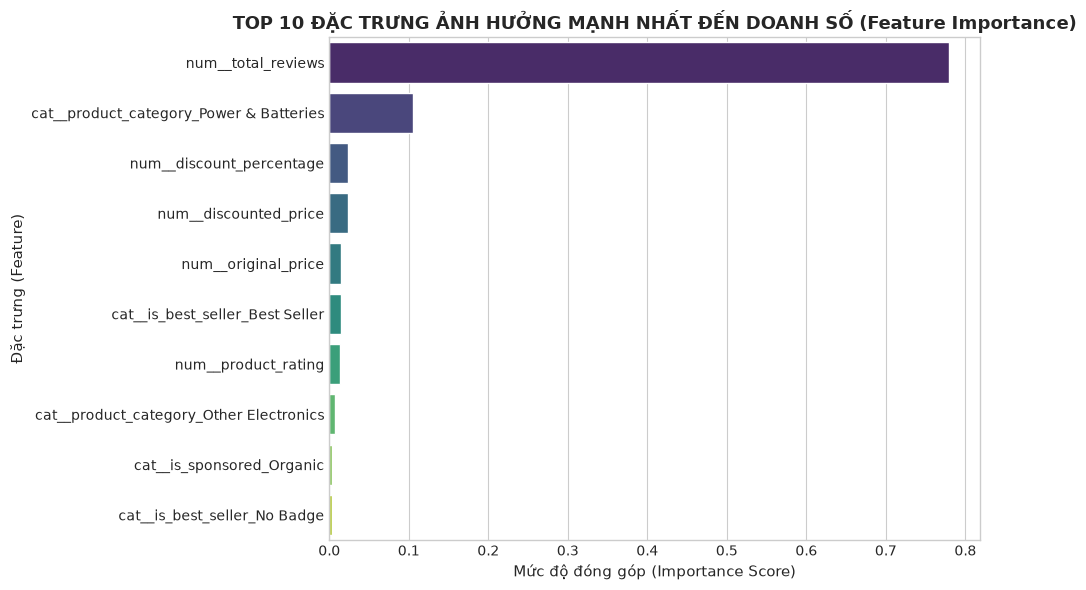


📊 TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT:


,Feature,Importance
1,num__total_reviews,0.779395
61,cat__product_category_Power & Batteries,0.104778
4,num__discount_percentage,0.023674
2,num__discounted_price,0.023036
3,num__original_price,0.014984
6,cat__is_best_seller_Best Seller,0.014647
0,num__product_rating,0.013965
59,cat__product_category_Other Electronics,0.006634
14,cat__is_sponsored_Organic,0.004035
9,cat__is_best_seller_No Badge,0.003935


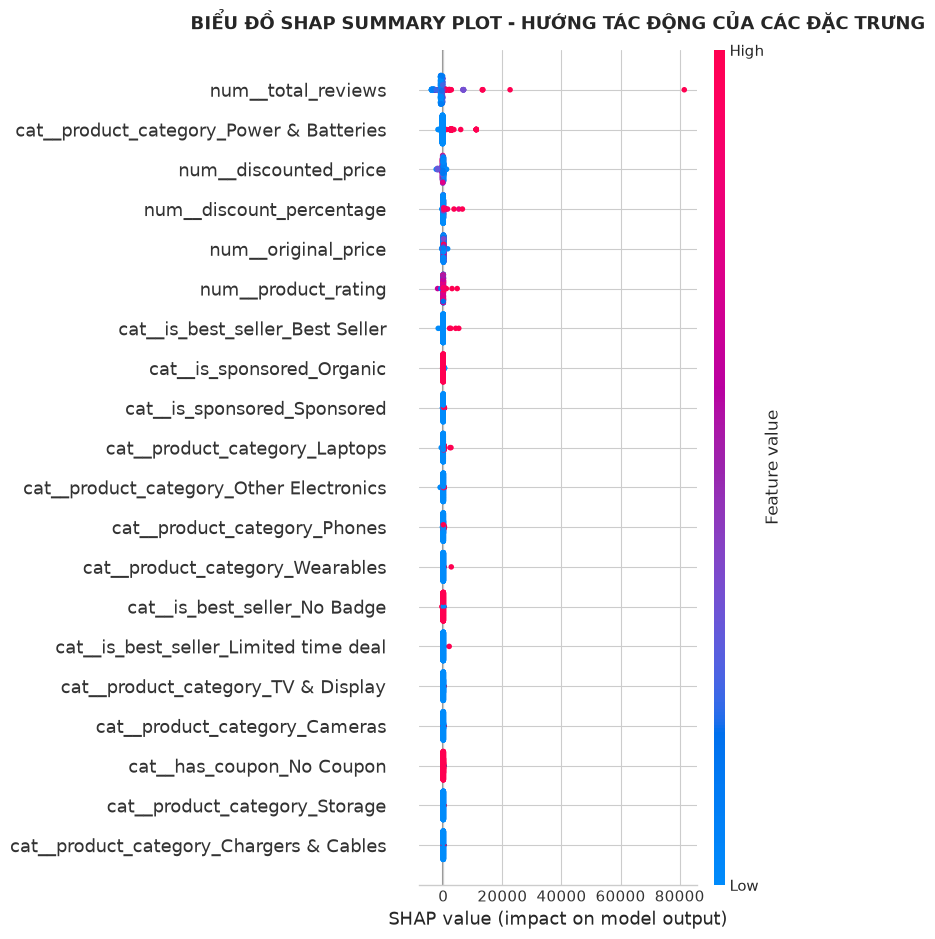

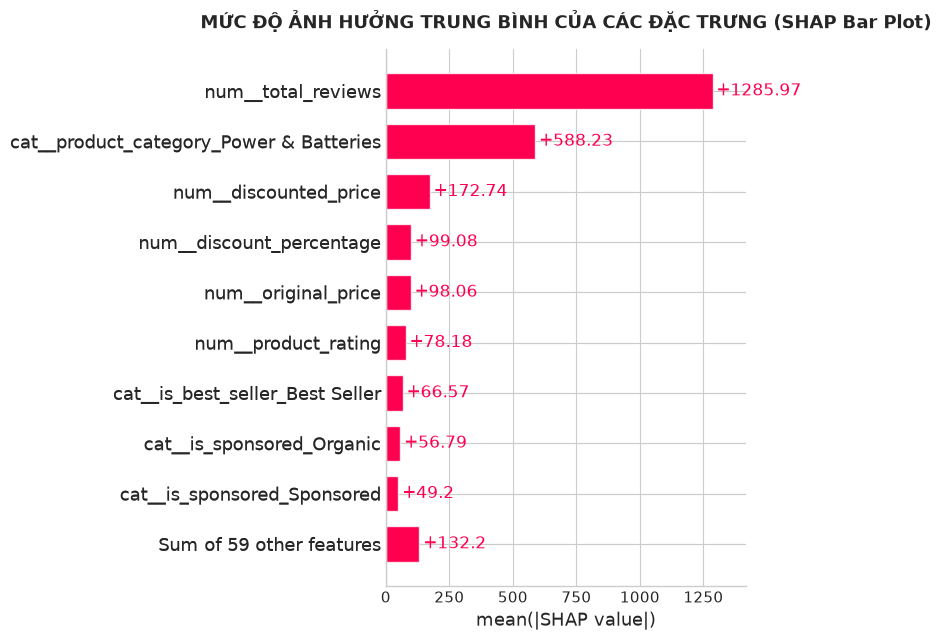

✅ Đã tính toán thành công và lưu trọn bộ biểu đồ tại thư mục: C:\Users\Thai Vi\PycharmProjects\Analyze&ForecastSaleSystem\data


In [9]:
import os
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

# Cấu hình phông chữ an toàn
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

print('⏳ Đang tính toán Feature Importance & SHAP Values từ File Model...')

# --- 1. XỬ LÝ ĐƯỜNG DẪN TỰ ĐỘNG ---
try:
  PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
  PROJECT_ROOT = Path('.').resolve().parent

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'saved_artifacts'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Tên file model trong saved_artifacts
model_path = (
    ARTIFACTS_DIR / 'random_forest_regressor_best_sales_model.joblib'
)

if not model_path.exists():
  raise FileNotFoundError(
      f"❌ Không tìm thấy file model tại: {model_path}. Vui lòng kiểm tra lại!"
  )

# --- 2. LOAD MODEL PIPELINE & TRÍCH XUẤT THÀNH PHẦN ---
best_full_pipeline = joblib.load(model_path)
print(f'✅ Đã load thành công Pipeline từ: {model_path.name}')

# Trích xuất regressor và preprocessor từ Pipeline
model_to_use = best_full_pipeline.named_steps['regressor']
preprocessor = best_full_pipeline.named_steps['preprocessor']

# Lấy danh sách tên đặc trưng sau khi qua preprocessor
feature_names = preprocessor.get_feature_names_out()

# ==========================================
# PHẦN 1: FEATURE IMPORTANCE
# ==========================================
if hasattr(model_to_use, 'feature_importances_'):
  importances = model_to_use.feature_importances_

  df_importance = pd.DataFrame(
      {'Feature': feature_names, 'Importance': importances}
  ).sort_values(by='Importance', ascending=False)

  plt.figure(figsize=(10, 6))
  sns.barplot(
      x='Importance',
      y='Feature',
      data=df_importance.head(10),
      palette='viridis',
  )
  plt.title(
      'TOP 10 ĐẶC TRƯNG ẢNH HƯỞNG MẠNH NHẤT ĐẾN DOANH SỐ (Feature Importance)',
      fontsize=13,
      fontweight='bold',
  )
  plt.xlabel('Mức độ đóng góp (Importance Score)', fontsize=11)
  plt.ylabel('Đặc trưng (Feature)', fontsize=11)
  plt.tight_layout()

  plt.savefig(
      DATA_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight'
  )
  plt.show()

  print('\n📊 TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT:')
  display(df_importance.head(10))

# ==========================================
# PHẦN 2: SHAP VALUES
# ==========================================
try:
  # Kiểm tra tập X_test
  if 'X_test' not in locals():
    raise NameError(
        "Chưa tìm thấy tập 'X_test' trong bộ nhớ để tính SHAP. Vui lòng chạy"
        ' cell train/test split trước.'
    )

  # Biến đổi X_test qua preprocessor
  X_test_trans = preprocessor.transform(X_test)

  # Lấy 500 mẫu đại diện
  X_sample_trans = (
      X_test_trans[:500] if len(X_test_trans) > 500 else X_test_trans
  )

  # Chuyển ma trận sparse/dense thành DataFrame có tên cột chuẩn cho SHAP
  if hasattr(X_sample_trans, 'toarray'):
    X_sample_trans = X_sample_trans.toarray()

  X_sample_df = pd.DataFrame(X_sample_trans, columns=feature_names)

  # Khởi tạo SHAP Explainer
  explainer = shap.TreeExplainer(model_to_use)
  shap_values = explainer(X_sample_df)

  if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 0]

  # Biểu đồ 1: SHAP Summary Plot
  plt.figure(figsize=(10, 6))
  shap.summary_plot(shap_values, X_sample_df, show=False)
  plt.title(
      'BIỂU ĐỒ SHAP SUMMARY PLOT - HƯỚNG TÁC ĐỘNG CỦA CÁC ĐẶC TRƯNG',
      fontsize=13,
      fontweight='bold',
      pad=15,
  )
  plt.tight_layout()
  plt.savefig(DATA_DIR / 'shap_summary_plot.png', dpi=300, bbox_inches='tight')
  plt.show()

  # Biểu đồ 2: SHAP Bar Plot
  plt.figure(figsize=(10, 6))
  shap.plots.bar(shap_values, max_display=10, show=False)
  plt.title(
      'MỨC ĐỘ ẢNH HƯỞNG TRUNG BÌNH CỦA CÁC ĐẶC TRƯNG (SHAP Bar Plot)',
      fontsize=13,
      fontweight='bold',
      pad=15,
  )
  plt.tight_layout()
  plt.savefig(DATA_DIR / 'shap_bar_plot.png', dpi=300, bbox_inches='tight')
  plt.show()

  print(
      f'✅ Đã tính toán thành công và lưu trọn bộ biểu đồ tại thư mục:'
      f' {DATA_DIR}'
  )

except Exception as e:
  print(f'⚠️ Lưu ý khi chạy SHAP: {e}')